In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
import matplotlib.pyplot as plt
import os
from google.colab import drive


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:


!unzip -q TrafficLabelling_.zip -d ./extracted_data
folder_path = "/content/TrafficLabelling_.zip"

replace ./extracted_data/TrafficLabelling_/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./extracted_data/TrafficLabelling_/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./extracted_data/TrafficLabelling_/Friday-WorkingHours-Morning.pcap_ISCX.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./extracted_data/TrafficLabelling_/Monday-WorkingHours.pcap_ISCX.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./extracted_data/TrafficLabelling_/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./extracted_data/TrafficLabelling_/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./extracted_data/TrafficLabelling_/Tuesday-WorkingHours.pcap_ISCX.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./extracted_data/TrafficLabelling_/Wednesday-workingHours.pcap_ISCX.csv? [y]

In [3]:
# ============================================================
# LOAD CIC-IDS2017 DATA (ROBUST + MEMORY SAFE)
# ============================================================

#folder_path = r"D:\Downloads\GeneratedLabelledFlows\TrafficLabelling_"
folder_path = "./extracted_data/TrafficLabelling_"
def load_cic(folder_path):
    dfs = []

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            print(f"Loading {file}...")

            df = pd.read_csv(
                os.path.join(folder_path, file),
                engine="python",
                encoding_errors="ignore"
            )

            df.columns = df.columns.str.strip()
            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    df['Label'] = (df['Label'] != 'BENIGN').astype(int)

    for col in df.columns:
        if col != "Label":
            df[col] = df[col].astype(np.float32)

    print("Dataset Loaded Successfully.")
    return df



In [4]:
# ============================================================
# NON-IID CLIENT CREATION
# ============================================================

def create_non_iid_clients(df, num_clients=5):
    clients = []

    benign = df[df['Label'] == 0]
    attack = df[df['Label'] == 1]

    attack_splits = np.array_split(
        attack.sample(frac=1, random_state=42),
        num_clients
    )

    for i in range(num_clients):

        attack_part = attack_splits[i]
        benign_part = benign.sample(
            min(len(benign), len(attack_part)//2),
            random_state=42
        )

        client_df = pd.concat([attack_part, benign_part]).sample(frac=1)

        X = client_df.drop("Label", axis=1).values.astype(np.float32)
        y = client_df["Label"]

        clients.append((X, y))

    return clients


#


In [5]:
# ============================================================
# MODEL
# ============================================================

class IDSModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [6]:


# ============================================================
# CENTRALIZED TRAINING (MINI-BATCH)
# ============================================================

def train_centralized(X_train, y_train, input_dim, epochs=5, batch_size=1024):

    model = IDSModel(input_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train.values, dtype=torch.float32)
    )

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for _ in range(epochs):
        model.train()

        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(), yb)
            loss.backward()
            optimizer.step()

    return model














In [7]:
# ============================================================
# FEDERATED UTILITIES
# ============================================================

def add_dp_noise(weights, sigma):
    for key in weights:
        noise = torch.normal(
            0, sigma,
            size=weights[key].shape,
            device=weights[key].device
        )
        weights[key] += noise
    return weights


def fed_avg(global_model, client_weights, client_sizes):
    global_dict = global_model.state_dict()
    total_samples = sum(client_sizes)

    for key in global_dict:
        global_dict[key] = sum(
            client_weights[i][key] * (client_sizes[i] / total_samples)
            for i in range(len(client_weights))
        )

    global_model.load_state_dict(global_dict)
    return global_model


def train_federated(clients, input_dim, rounds=3, local_epochs=1,
                    batch_size=1024, dp_sigma=0):

    global_model = IDSModel(input_dim).to(DEVICE)
    communication_cost = 0

    for r in range(rounds):
        print(f"Federated Round {r+1}/{rounds}")

        client_weights = []
        client_sizes = []

        for X_local, y_local in clients:

            model = deepcopy(global_model)
            optimizer = optim.Adam(model.parameters(), lr=0.001)
            criterion = nn.BCEWithLogitsLoss()

            dataset = TensorDataset(
                torch.tensor(X_local, dtype=torch.float32),
                torch.tensor(y_local.values, dtype=torch.float32)
            )

            loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

            for _ in range(local_epochs):
                model.train()

                for xb, yb in loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                    optimizer.zero_grad()
                    loss = criterion(model(xb).squeeze(), yb)
                    loss.backward()
                    optimizer.step()

            weights = model.state_dict()

            if dp_sigma > 0:
                weights = add_dp_noise(weights, dp_sigma)

            client_weights.append(weights)
            client_sizes.append(len(y_local))

            for key in weights:
                communication_cost += weights[key].numel() * 4

        global_model = fed_avg(global_model, client_weights, client_sizes)

    return global_model, communication_cost

In [8]:
# ============================================================
# EVALUATION (with ROC-AUC + Confusion Matrix)
# ============================================================

def evaluate(model, X_test, y_test):
    model.eval()

    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        probs = torch.sigmoid(model(X_tensor)).squeeze().cpu().numpy()

    preds = (probs > 0.5).astype(int)

    return {
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probs),
        "ConfusionMatrix": confusion_matrix(y_test, preds),
        "Probs": probs,
        "Preds": preds
    }


In [9]:
# ============================================================
# EPSILON ACCOUNTING
# ============================================================

def compute_epsilon(sigma, rounds, delta=1e-5):
    if sigma == 0:
        return np.inf
    return rounds / (sigma**2) * np.log(1/delta)



In [10]:
# ============================================================
# VISUALIZATION (Metrics + Communication Cost)
# ============================================================

def plot_results(central, fed, fed_dp, fed_comm, fed_dp_comm):

    # Metrics plot
    labels = ['Precision', 'Recall', 'F1', 'ROC-AUC']
    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(10,6))
    plt.bar(x - width, [central[m] for m in labels], width, label='Centralized')
    plt.bar(x, [fed[m] for m in labels], width, label='Federated')
    plt.bar(x + width, [fed_dp[m] for m in labels], width, label='Federated + DP')
    plt.xticks(x, labels)
    plt.ylabel("Score")
    plt.title("Centralized vs Federated vs Secure Federated")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Communication cost plot
    plt.figure(figsize=(6,4))
    plt.bar(['Federated', 'Federated+DP'], [fed_comm, fed_dp_comm])
    plt.ylabel("Bytes Transferred")
    plt.title("Communication Cost")
    plt.tight_layout()
    plt.show()



Loading Dataset...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Tuesday-WorkingHours.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Loading Monday-WorkingHours.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Loading Wednesday-workingHours.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Dataset Loaded Successfully.
Scaler saved successfully!


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Training Centralized...
Training Federated...
Federated Round 1/3
Federated Round 2/3
Federated Round 3/3
Training Federated + DP...
Federated Round 1/3
Federated Round 2/3
Federated Round 3/3

Centralized: {'Precision': 0.9646586565717525, 'Recall': 0.947767965430191, 'F1': 0.9561387210941076, 'ROC-AUC': np.float64(0.9986119606382255), 'ConfusionMatrix': array([[450400,   3865],
       [  5814, 105497]]), 'Probs': array([4.2146033e-01, 9.9941421e-01, 2.8953469e-01, ..., 1.0241095e-10,
       7.3886264e-13, 2.6184157e-09], dtype=float32), 'Preds': array([0, 1, 0, ..., 0, 0, 0])}
Federated: {'Precision': 0.7863960286189778, 'Recall': 0.9933609436623514, 'F1': 0.87784468694054, 'ROC-AUC': np.float64(0.9939998320367481), 'ConfusionMatrix': array([[424231,  30034],
       [   739, 110572]]), 'Probs': array([9.4694757e-01, 9.9427587e-01, 7.1662021e-01, ..., 3.9807426e-05,
       1.7859567e-03, 1.4833892e-02], dtype=float32), 'Preds': array([1, 1, 1, ..., 0, 0, 0])}
Federated + DP: {'Precisi

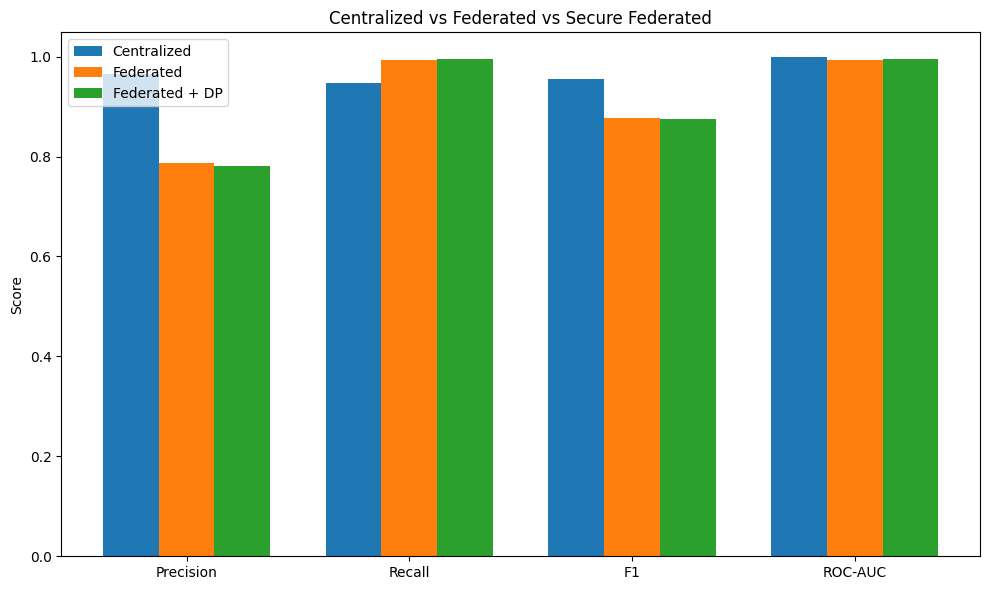

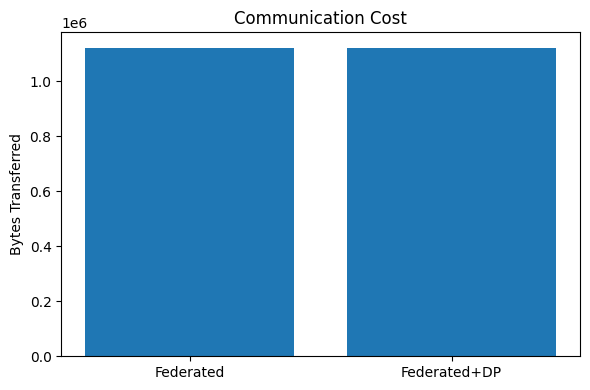

In [11]:
# ============================================================
# MAIN
# ============================================================

print("Loading Dataset...")
df = load_cic(folder_path)

X = df.drop("Label", axis=1)
y = df["Label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)


import joblib

# Save scaler
joblib.dump(scaler, "feature_scaler.pkl")

print("Scaler saved successfully!")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

train_df = pd.DataFrame(X_train)
train_df["Label"] = y_train.values

clients = create_non_iid_clients(train_df, num_clients=5)

input_dim = X_train.shape[1]

print("Training Centralized...")
central_model = train_centralized(X_train, y_train, input_dim)

print("Training Federated...")
fed_model, fed_comm = train_federated(clients, input_dim)

print("Training Federated + DP...")
fed_dp_model, fed_dp_comm = train_federated(clients, input_dim, dp_sigma=0.01)

central_metrics = evaluate(central_model, X_test, y_test)
fed_metrics = evaluate(fed_model, X_test, y_test)
fed_dp_metrics = evaluate(fed_dp_model, X_test, y_test)

epsilon = compute_epsilon(sigma=0.01, rounds=3)

print("\nCentralized:", central_metrics)
print("Federated:", fed_metrics)
print("Federated + DP:", fed_dp_metrics)
print(f"Approximate Epsilon for DP: {epsilon:.4f}")

plot_results(central_metrics, fed_metrics, fed_dp_metrics, fed_comm, fed_dp_comm)




In [12]:
# ============================================================
# ADDITIONAL VISUALIZATION: CONFUSION MATRIX + EPSILON
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrices(central, fed, fed_dp, epsilon_dp=None):
    """
    Plots confusion matrices for Centralized, Federated, and Federated + DP models.
    If epsilon_dp is provided, it will be displayed in the DP model caption.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18,5))

    models = [central, fed, fed_dp]
    titles = ['Centralized', 'Federated', 'Federated + DP']

    for i, ax in enumerate(axes):
        cm = models[i]['ConfusionMatrix']
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, colorbar=False)

        # Add epsilon in DP caption
        if titles[i] == 'Federated + DP' and epsilon_dp is not None:
            ax.set_title(f"{titles[i]}\n(Epsilon ≈ {epsilon_dp:.2f})")
        else:
            ax.set_title(titles[i])

    plt.tight_layout()
    plt.show()

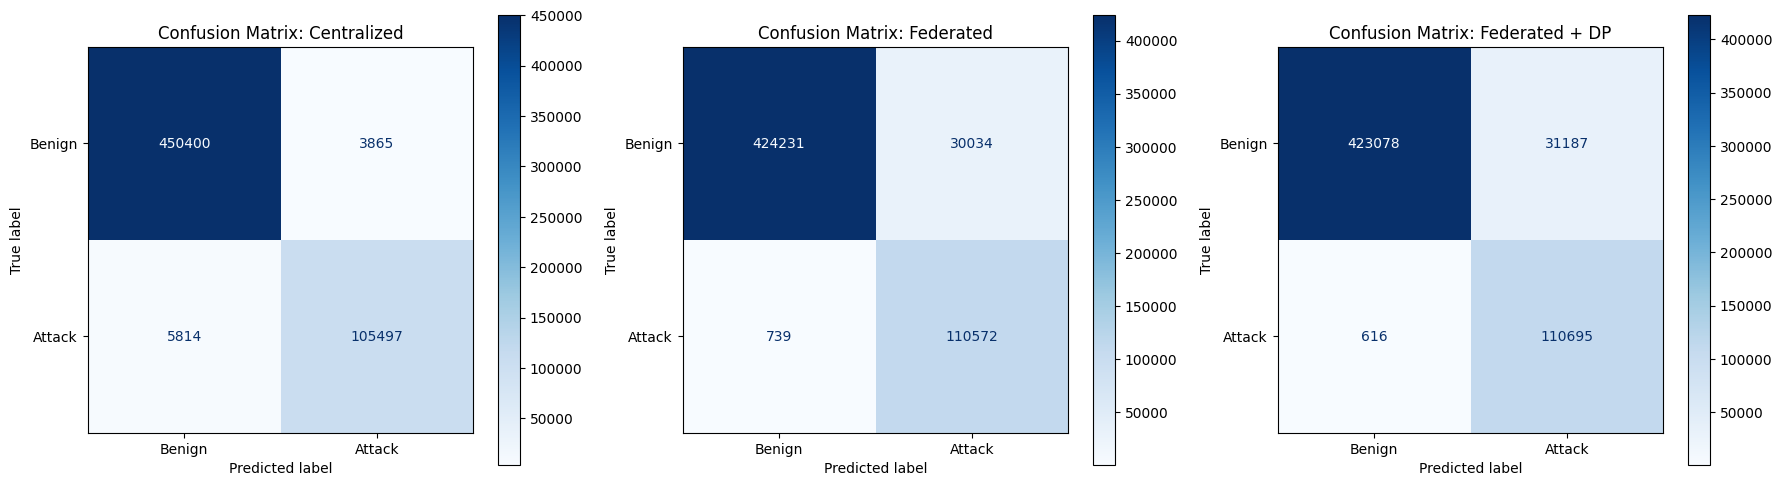

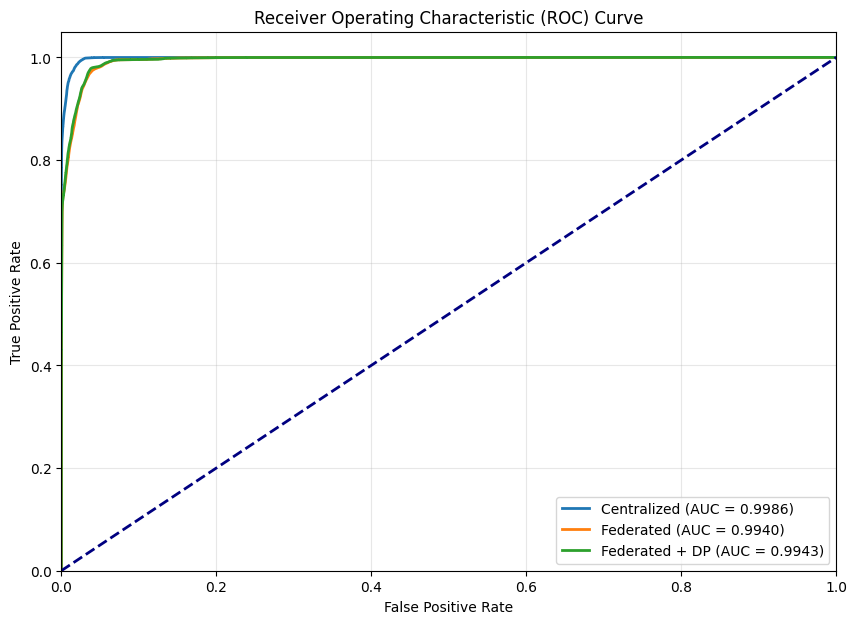

In [14]:
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

def plot_detailed_evaluations(central, fed, fed_dp, y_test):
    # 1. SETUP PLOT FOR CONFUSION MATRICES
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics_list = [central, fed, fed_dp]
    titles = ['Centralized', 'Federated', 'Federated + DP']

    for i, ax in enumerate(axes):
        cm = metrics_list[i]['ConfusionMatrix']
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
        disp.plot(ax=ax, cmap='Blues', values_format='d')
        ax.set_title(f"Confusion Matrix: {titles[i]}")

    plt.tight_layout()
    plt.show()

    # 2. SETUP PLOT FOR ROC CURVES
    plt.figure(figsize=(10, 7))

    for i, m in enumerate(metrics_list):
        fpr, tpr, _ = roc_curve(y_test, m['Probs'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{titles[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Call the function using your existing variables
plot_detailed_evaluations(central_metrics, fed_metrics, fed_dp_metrics, y_test)

In [13]:
# ============================
# Save Final Global Model
# ============================

model_save_path = "global_federated_ids_model.pth"


# Use torch.save() for PyTorch models
torch.save(fed_model.state_dict(), model_save_path)

print("\nGlobal Federated Model saved successfully!")
print("Model path:", model_save_path)


Global Federated Model saved successfully!
Model path: global_federated_ids_model.pth
